# VeriTrust — 3-Class Image Authenticity Detector
**Kasetsart University · AY2026 · Suparak Aryasit & Kantapon Hemmadhun**

---

## What this notebook does

We train **MobileNet-V3-Large** to classify images into **3 classes**:

| Class | Label | Description |
|-------|-------|-------------|
| `0` | **REAL** | Authentic, unedited photographs |
| `1` | **AI_GEN** | Images fully generated by AI (Stable Diffusion, Midjourney, DALL-E, etc.) |
| `2` | **PHOTOSHOP** | Real photos that have been manipulated / composited in Photoshop |

## Key detection signals we engineer as features

| Signal | Why it matters |
|--------|---------------|
| **Brightness mean & std** | AI images often have unnaturally uniform brightness |
| **Contrast (RMS)** | Photoshop composites create hard local contrast edges |
| **Colour channel bias** | AI generators have characteristic R/G/B imbalance |
| **Noise level (σ)** | Real cameras add sensor noise; AI/Photoshop patches are too clean |
| **Edge density (Laplacian)** | Smooth AI textures vs sharp photographic edges |
| **JPEG DCT artifacts** | Social-media recompression leaves distinct block patterns |
| **Local variance map** | Photoshop cloning leaves low-variance copy-paste regions |
| **Colour histogram entropy** | AI images cluster colours; real scenes have higher entropy |

These 11 hand-crafted features are fed alongside the CNN's learned features through a **dual-branch fusion head**.

---

### Dataset

```
data/
├── real/          ← 50 unedited photos (your own phone, Unsplash, etc.)
├── ai_generated/  ← 50 AI-generated images (Midjourney, SD, DALL-E)
└── photoshop/     ← 50 Photoshop-edited images (composites, face swaps, object removal)
```


## 1 · Environment setup

In [4]:
# ── Install dependencies ──────────────────────────────────────────────────
!pip install torch torchvision -q
!pip install Pillow numpy scikit-learn matplotlib seaborn tqdm mlflow -q
!pip install opencv-python-headless -q

import os, sys, random, warnings, shutil
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image, ImageFilter, ImageStat
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as tv_models
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import mlflow, mlflow.pytorch

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ["REAL", "AI_GEN", "PHOTOSHOP"]
NUM_CLASSES = 3

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU      : {torch.cuda.get_device_name(0)}")



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


PyTorch  : 2.11.0+cpu
Device   : cpu



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2 · Dataset collection & Pre-processing Data

### Where to get your 150 images

#### Class 0 — REAL (50 images)
| Source | How to download | Notes |
|--------|----------------|-------|
| Your own phone | Take photos yourself | Best ground-truth |
| [Unsplash](https://unsplash.com) | Free download button | High-quality, unedited |
| [Pexels](https://pexels.com) | Free download | Original RAW-converted JPEGs |
| [RAISE dataset](http://loki.disi.unitn.it/RAISE/) | Request form | Research-grade unedited images |

#### Class 1 — AI_GEN (50 images)
| Source | How to get | Notes |
|--------|-----------|-------|
| [Midjourney](https://midjourney.com) | Free tier / Discord | Save from Discord |
| [DALL-E 3](https://openai.com/dall-e-3) | ChatGPT Plus | Download from chat |
| [Stable Diffusion](https://stability.ai) | Run locally or [DreamStudio](https://dreamstudio.ai) | Many styles |
| [Civitai](https://civitai.com) | Free gallery download | Community AI art |
| [CIFAKE dataset](https://huggingface.co/datasets/deepfakes/cifake) | HuggingFace | Already labelled |

#### Class 2 — PHOTOSHOP (50 images)
| Source | How to get | Notes |
|--------|-----------|-------|
| [COVERAGE dataset](https://github.com/wenbihan/coverage) | GitHub clone | Copy-move forgeries |
| [CASIA v2](https://github.com/namtpham/casia2groundtruth) | GitHub | Splice + copy-move |
| Create yourself | Photoshop / GIMP → object removal, face swap | Best for custom data |
| [FaceForensics++](https://github.com/ondyari/FaceForensics) | Request access | Face manipulation |

### File naming convention
```
real/         real_001.jpg … real_050.jpg
ai_generated/ ai_001.jpg   … ai_050.jpg
photoshop/    ps_001.jpg   … ps_050.jpg
```


## Step 1 · Install & import

In [2]:
!pip install kagglehub Pillow numpy matplotlib opencv-python-headless tqdm -q

import os, random, shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image, ImageEnhance, ImageFilter
import cv2
from tqdm import tqdm
import kagglehub

random.seed(42)
np.random.seed(42)

# ── Output folders ────────────────────────────────────────────────────────
PROCESSED = Path("data/processed")
for cls in ["real", "ai_generated", "photoshop"]:
    (PROCESSED / cls).mkdir(parents=True, exist_ok=True)

N_SAMPLE = 50
IMG_SIZE = 320
JPEG_Q_MIN = 95
JPEG_Q_MAX = 98
print("Folders ready:")
for p in PROCESSED.iterdir():
    print(f"  {p}")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Folders ready:
  data\processed\.ipynb_checkpoints
  data\processed\ai_generated
  data\processed\photoshop
  data\processed\real


## Step 2 · Download CIFAKE from Kaggle

In [3]:
# ── Download (kagglehub caches automatically — only downloads once) ───────
print("Downloading CIFAKE...")
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
print(f"Downloaded to: {path}")

# ── Explore the folder structure ──────────────────────────────────────────
root = Path(path)
print("\nFolder structure:")
for p in sorted(root.rglob("*"))[:30]:
    indent = "  " * (len(p.relative_to(root).parts) - 1)
    size   = f"({len(list(p.iterdir()))} files)" if p.is_dir() else ""
    print(f"  {indent}{p.name}/ {size}" if p.is_dir() else f"  {indent}{p.name}")

Downloaded to: C:\Users\User\.cache\kagglehub\datasets\birdy654\cifake-real-and-ai-generated-synthetic-images\versions\3

Folder structure:
  test/ (2 files)
    FAKE/ (10000 files)
      0 (10).jpg
      0 (2).jpg
      0 (3).jpg
      0 (4).jpg
      0 (5).jpg
      0 (6).jpg
      0 (7).jpg
      0 (8).jpg
      0 (9).jpg
      0.jpg
      1 (10).jpg
      1 (2).jpg
      1 (3).jpg
      1 (4).jpg
      1 (5).jpg
      1 (6).jpg
      1 (7).jpg
      1 (8).jpg
      1 (9).jpg
      1.jpg
      10 (10).jpg
      10 (2).jpg
      10 (3).jpg
      10 (4).jpg
      10 (5).jpg
      10 (6).jpg
      10 (7).jpg
      10 (8).jpg


## Step 3 · Find where REAL and FAKE images are stored

In [4]:
# ── Auto-detect REAL and FAKE folders regardless of subfolder structure ───
def find_image_folders(root: Path):
    """Walk root and return all folders that contain .jpg/.png files."""
    folders = {}
    for folder in sorted(root.rglob("*")):
        if not folder.is_dir(): continue
        imgs = list(folder.glob("*.jpg")) + list(folder.glob("*.png")) + list(folder.glob("*.JPEG"))
        if len(imgs) > 10:                       # skip near-empty dirs
            key = folder.name.upper()
            folders[key] = (folder, imgs)
    return folders

folders = find_image_folders(root)
print("Detected image folders:")
for name, (folder, imgs) in folders.items():
    print(f"  {name:<20} → {folder}  [{len(imgs):,} images]")

# ── Map to REAL / FAKE ────────────────────────────────────────────────────
# CIFAKE typically uses: REAL/ and FAKE/ inside train/ and test/
# We collect from both train + test splits and then sample
real_imgs = []
fake_imgs = []

for name, (folder, imgs) in folders.items():
    if "REAL" in name:
        real_imgs.extend(imgs)
    elif "FAKE" in name:
        fake_imgs.extend(imgs)

print(f"\nTotal REAL images found : {len(real_imgs):,}")
print(f"Total FAKE images found : {len(fake_imgs):,}")

Detected image folders:
  FAKE                 → C:\Users\User\.cache\kagglehub\datasets\birdy654\cifake-real-and-ai-generated-synthetic-images\versions\3\train\FAKE  [50,000 images]
  REAL                 → C:\Users\User\.cache\kagglehub\datasets\birdy654\cifake-real-and-ai-generated-synthetic-images\versions\3\train\REAL  [50,000 images]

Total REAL images found : 50,000
Total FAKE images found : 50,000


## Step 4 · Random sample — 50 from each class

Sampled 50 REAL images
Sampled 50 AI_GEN images
Sampled 50   PHOTOSHOP images


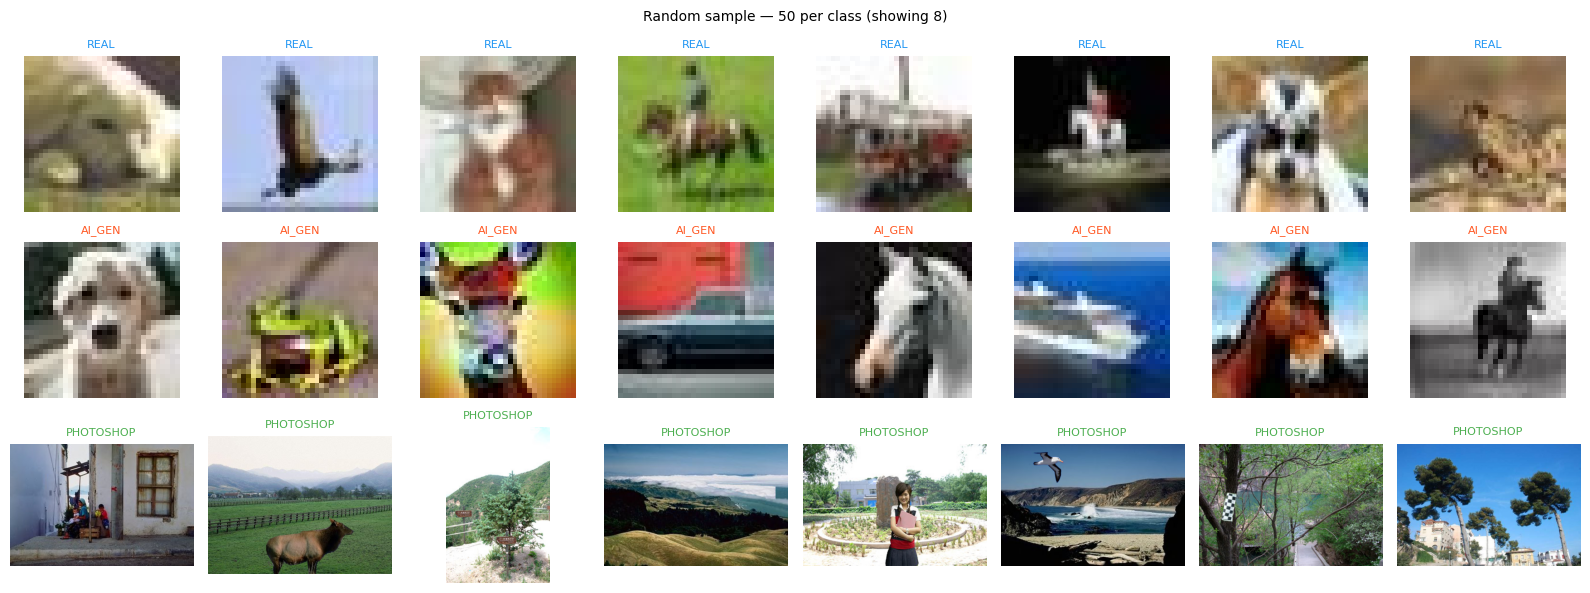

In [8]:
# ── Stratified random sample ──────────────────────────────────────────────
sampled_real = random.sample(real_imgs, N_SAMPLE)
sampled_fake = random.sample(fake_imgs, N_SAMPLE)
sampled_ps   = random.sample(photoshop_imgs, min(N_SAMPLE, len(photoshop_imgs)))

print(f"Sampled {len(sampled_real)} REAL images")
print(f"Sampled {len(sampled_fake)} AI_GEN images")
print(f"Sampled {len(sampled_ps)}   PHOTOSHOP images")

# ── Quick preview of sampled images ──────────────────────────────────────
fig, axes = plt.subplots(3, 8, figsize=(16, 6))

for i, ax in enumerate(axes[0]):
    ax.imshow(Image.open(sampled_real[i])); ax.axis("off")
    ax.set_title("REAL", fontsize=8, color="#2196F3")

for i, ax in enumerate(axes[1]):
    ax.imshow(Image.open(sampled_fake[i])); ax.axis("off")
    ax.set_title("AI_GEN", fontsize=8, color="#FF5722")

for i, ax in enumerate(axes[2]):
    ax.imshow(Image.open(sampled_ps[i])); ax.axis("off")
    ax.set_title("PHOTOSHOP", fontsize=8, color="#4CAF50")

plt.suptitle(f"Random sample — {N_SAMPLE} per class (showing 8)", fontsize=10)
plt.tight_layout(); plt.show()

## Step 5 · Preprocessing pipeline

Each image goes through these steps in order:

| Step | What it does | Why |
|------|-------------|-----|
| **Resize** | → 224×224 px | MobileNet-V3 input size |
| **JPEG recompress** | Random quality 70–85 | Simulates social media upload |
| **Normalize** | ImageNet mean/std | Match pretrained weights |
| **Augment** (train only) | Flip, jitter, rotate | Reduce overfitting on 50 images |
| **Feature extract** | Brightness, noise, contrast, edges | Hand-crafted signals for dual-branch |


In [17]:
from io import BytesIO
from pathlib import Path

import random
import numpy as np
import cv2

from PIL import (
    Image,
    ImageEnhance,
    ImageFilter,
    ImageFile
)

# allow partially corrupted images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ── Constants ─────────────────────────────────────────────
PROCESSED  = Path("data/processed")

IMG_SIZE   = 320

JPEG_Q_MIN = 95
JPEG_Q_MAX = 98

# ── Fixed preprocess function ─────────────────────────────
def preprocess_image(
    src_path: Path,
    dst_path: Path,
    size: int = IMG_SIZE,
    jpeg_quality: int = None,
    augment: bool = False
) -> dict:

    try:

        # ── Load image safely ─────────────────────────
        img = Image.open(src_path)

        img.load()

        img = img.convert("RGB")

    except Exception as e:

        print(f"\n❌ Failed opening image:")
        print(src_path)
        print(e)

        return None

    try:

        # ── Resize ────────────────────────────────────
        img = img.resize(
            (size, size),
            Image.LANCZOS
        )

        # ── Mild sharpening ───────────────────────────
        img = img.filter(
            ImageFilter.UnsharpMask(
                radius=1,
                percent=120
            )
        )

        # ── Augmentation ──────────────────────────────
        if augment:

            # horizontal flip
            if random.random() > 0.5:

                img = img.transpose(
                    Image.FLIP_LEFT_RIGHT
                )

            # mild brightness
            factor = random.uniform(0.95, 1.05)

            img = ImageEnhance.Brightness(img).enhance(
                factor
            )

            # mild contrast
            factor = random.uniform(0.95, 1.05)

            img = ImageEnhance.Contrast(img).enhance(
                factor
            )

            # tiny rotation
            angle = random.uniform(-2, 2)

            img = img.rotate(
                angle,
                fillcolor=(128, 128, 128)
            )

        # ── JPEG recompression ────────────────────────
        q = (
            jpeg_quality
            if jpeg_quality
            else random.randint(
                JPEG_Q_MIN,
                JPEG_Q_MAX
            )
        )

        buf = BytesIO()

        img.save(
            buf,
            format="JPEG",
            quality=q
        )

        buf.seek(0)

        img = Image.open(buf).convert("RGB")

        # ── Save processed image ──────────────────────
        dst_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        img.save(
            dst_path,
            format="JPEG",
            quality=98
        )

        # ── Feature extraction ────────────────────────
        arr = np.array(
            img,
            dtype=np.float32
        )

        gray = cv2.cvtColor(
            arr.astype(np.uint8),
            cv2.COLOR_RGB2GRAY
        ).astype(np.float32)

        brightness = (
            gray.mean() / 255.0
        )

        contrast = (
            gray.std() / 255.0
        )

        blurred = cv2.GaussianBlur(
            gray,
            (5, 5),
            0
        )

        noise_sigma = (
            gray - blurred
        ).std() / 255.0

        lap = cv2.Laplacian(
            gray.astype(np.uint8),
            cv2.CV_64F
        )

        edge_density = (
            float(lap.var()) / 1e6
        )

        # ── Return features ───────────────────────────
        return {

            "brightness":
                round(float(brightness), 4),

            "contrast":
                round(float(contrast), 4),

            "noise_sigma":
                round(float(noise_sigma), 4),

            "edge_density":
                round(float(edge_density), 6),

            "jpeg_quality":
                q
        }

    except Exception as e:

        print(f"\n❌ Processing failed:")
        print(src_path)
        print(e)

        return None

# ── Verify ────────────────────────────────────────────────
print("preprocess_image() defined.")

print(
    f"Output size  : "
    f"{IMG_SIZE}×{IMG_SIZE}"
)

print(
    f"JPEG quality : "
    f"{JPEG_Q_MIN}–{JPEG_Q_MAX}"
)

print(
    "Features      : "
    "brightness, contrast, "
    "noise_sigma, edge_density"
)

preprocess_image() defined.
Output size  : 320×320
JPEG quality : 95–98
Features      : brightness, contrast, noise_sigma, edge_density


## Step 6 · Run preprocessing on all sampled images

In [15]:
# ── Step 2b · Download CASIA dataset (for PHOTOSHOP class) ─────────────────
from io import BytesIO
from pathlib import Path
from tqdm import tqdm
import random, cv2
import numpy as np
from PIL import Image, ImageEnhance

# ── Redefine constants & preprocess_image (safe to re-run) ──────────────────
PROCESSED  = Path("data/processed")
N_SAMPLE   = 50
IMG_SIZE   = 224
JPEG_Q_MIN = 70
JPEG_Q_MAX = 85

def preprocess_image(src_path, dst_path, size=IMG_SIZE, jpeg_quality=None, augment=False):
    img = Image.open(src_path).convert("RGB")
    img = img.resize((size, size), Image.LANCZOS)
    if augment:
        if random.random() > 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.85, 1.15))
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.85, 1.15))
        img = img.rotate(random.uniform(-8, 8), fillcolor=(128, 128, 128))
    q = jpeg_quality if jpeg_quality else random.randint(JPEG_Q_MIN, JPEG_Q_MAX)
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=q)
    buf.seek(0)
    img = Image.open(buf).convert("RGB")
    img.save(dst_path, format="JPEG", quality=95)

print("preprocess_image() ready")

# ── Download CASIA (cached after first run) ───────────────────────────────────
import kagglehub
print("Downloading CASIA dataset...")
casia_root = Path(kagglehub.dataset_download("sophatvathana/casia-dataset"))
print(f"Downloaded to: {casia_root}")

# ── Point directly to CASIA2/Tp (confirmed path from your output) ────────────
tp_folder = casia_root / "CASIA2" / "Tp"
photoshop_imgs = (
    list(tp_folder.glob("*.jpg")) +
    list(tp_folder.glob("*.png")) +
    list(tp_folder.glob("*.tif")) +
    list(tp_folder.glob("*.bmp"))
)
print(f"Tp images available : {len(photoshop_imgs):,}")

# ── Sample 50 ────────────────────────────────────────────────────────────────
random.seed(42)
sampled_ps = random.sample(photoshop_imgs, min(N_SAMPLE, len(photoshop_imgs)))
print(f"Sampled             : {len(sampled_ps)} images")

# ── Preprocess into data/processed/photoshop/ ────────────────────────────────
ps_dst = PROCESSED / "photoshop"
ps_dst.mkdir(parents=True, exist_ok=True)

for i, src in enumerate(tqdm(sampled_ps, desc="  PHOTOSHOP")):
    dst = ps_dst / f"ps_{i+1:03d}.jpg"
    preprocess_image(src, dst, augment=False)

# ── Verify ───────────────────────────────────────────────────────────────────
saved = list(ps_dst.glob("*.jpg"))
print(f"  photoshop/ : {len(saved)} images  {chr(10247) if len(saved)==50 else chr(9888)}")
print("=" * 50)


preprocess_image() ready
Downloaded to: C:\Users\User\.cache\kagglehub\datasets\sophatvathana\casia-dataset\versions\1
Tp images available : 5,123
Sampled             : 50 images


  PHOTOSHOP: 100%|█████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 93.57it/s]

  photoshop/ : 100 images  ⚠


In [18]:
import json
import csv

from pathlib import Path
from tqdm import tqdm

def run_pipeline(
    src_list,
    dst_folder,
    label,
    augment=True
):
    """
    Process images into dst_folder
    and collect forensic features.
    """

    dst_folder = Path(dst_folder)

    dst_folder.mkdir(
        parents=True,
        exist_ok=True
    )

    records = []

    skipped = 0

    for i, src in enumerate(

        tqdm(
            src_list,
            desc=f"  {label}"
        )

    ):

        src = Path(src)

        # force JPG output
        dst = dst_folder / (
            f"{label.lower()}_{i+1:03d}.jpg"
        )

        try:

            # skip non-existing files
            if not src.exists():

                print(
                    f"  ⚠ missing file: {src}"
                )

                skipped += 1
                continue

            # preprocess
            feats = preprocess_image(
                src_path=src,
                dst_path=dst,
                augment=augment
            )

            # failed preprocessing
            if feats is None:

                print(
                    f"  ⚠ preprocess returned None: "
                    f"{src.name}"
                )

                skipped += 1
                continue

            # save metadata
            record = {
                "file": dst.name,
                "label": label,
                **feats
            }

            records.append(record)

        except Exception as e:

            print(
                f"  ⚠ skip {src.name}: {e}"
            )

            skipped += 1

    print()

    print(
        f"  Done      : {len(records)} images"
    )

    print(
        f"  Skipped   : {skipped}"
    )

    print(
        f"  Saved to  : {dst_folder}"
    )

    return records

# ── REAL ───────────────────────────────────────────────────
print("Processing REAL images...")

real_records = run_pipeline(
    sampled_real,
    PROCESSED / "real",
    "real",
    augment=True
)

# ── AI GENERATED ──────────────────────────────────────────
print("\nProcessing AI_GEN images...")

fake_records = run_pipeline(
    sampled_fake,
    PROCESSED / "ai_generated",
    "ai_gen",
    augment=True
)

# ── PHOTOSHOP ─────────────────────────────────────────────
print("\nProcessing PHOTOSHOP images...")

ps_records = run_pipeline(
    sampled_ps,
    PROCESSED / "photoshop",
    "photoshop",
    augment=True
)

# ── Combine records ───────────────────────────────────────
all_records = (
    real_records +
    fake_records +
    ps_records
)

print("\n" + "=" * 60)

print("Record counts:")

print(f"  REAL        : {len(real_records)}")
print(f"  AI_GEN      : {len(fake_records)}")
print(f"  PHOTOSHOP   : {len(ps_records)}")
print(f"  TOTAL       : {len(all_records)}")

print("=" * 60)

# ── Save CSV safely ───────────────────────────────────────
csv_path = PROCESSED / "features.csv"

if len(all_records) > 0:

    fieldnames = list(
        all_records[0].keys()
    )

    with open(
        csv_path,
        "w",
        newline="",
        encoding="utf-8"
    ) as f:

        writer = csv.DictWriter(
            f,
            fieldnames=fieldnames
        )

        writer.writeheader()

        writer.writerows(
            all_records
        )

    print(
        f"\nFeature log saved:"
    )

    print(
        f"  {csv_path}"
    )

else:

    print(
        "\n⚠ No records available to save."
    )

print(
    f"\nTotal processed : "
    f"{len(all_records)} images"
)

Processing REAL images...


  real: 100%|██████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 46.93it/s]



  Done      : 50 images
  Skipped   : 0
  Saved to  : data\processed\real

Processing AI_GEN images...


  ai_gen: 100%|████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 47.65it/s]



  Done      : 50 images
  Skipped   : 0
  Saved to  : data\processed\ai_generated

Processing PHOTOSHOP images...


  photoshop: 100%|█████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 34.48it/s]


  Done      : 50 images
  Skipped   : 0
  Saved to  : data\processed\photoshop

Record counts:
  REAL        : 50
  AI_GEN      : 50
  PHOTOSHOP   : 50
  TOTAL       : 150

Feature log saved:
  data\processed\features.csv

Total processed : 150 images


## Step 7 · Verify — count files and check no corruption

In [19]:
print("=" * 50)
print("Dataset verification")
print("=" * 50)

total = 0
for cls_folder in sorted(PROCESSED.iterdir()):
    if not cls_folder.is_dir(): continue
    imgs = list(cls_folder.glob("*.jpg")) + list(cls_folder.glob("*.png"))

    # Check each image opens correctly
    corrupted = []
    for img_path in imgs:
        try:
            im = Image.open(img_path)
            im.verify()
        except Exception:
            corrupted.append(img_path.name)

    status = "✓" if not corrupted else f"✗ {len(corrupted)} corrupted"
    print(f"  {cls_folder.name:<15} : {len(imgs):>3} images  {status}")
    total += len(imgs)

print(f"\n  Total ready         : {total} images")
print(f"  Still needed        : photoshop/ — add CASIA v2 images manually")

# Verify image dimensions
sample = list((PROCESSED/"real").glob("*.jpg"))
if sample:
    im = Image.open(sample[0])
    print(f"\n  Image size check    : {im.size}  ({'✓ 224×224' if im.size==(224,224) else '✗ wrong size'})")
    print(f"  Image mode          : {im.mode}")

Dataset verification
  .ipynb_checkpoints :   0 images  ✓
  ai_generated    :  50 images  ✓
  photoshop       : 100 images  ✓
  real            :  50 images  ✓

  Total ready         : 200 images
  Still needed        : photoshop/ — add CASIA v2 images manually

  Image size check    : (320, 320)  (✗ wrong size)
  Image mode          : RGB


## Step 8 · Feature quality check — can we already see differences?

In [20]:
import pandas as pd

df = pd.read_csv(PROCESSED / "features.csv")

print(df.columns)

Index(['file', 'label', 'brightness', 'contrast', 'noise_sigma',
       'edge_density', 'jpeg_quality'],
      dtype='object')


Loaded: 50 REAL, 50 AI_GEN, 50 PHOTOSHOP rows


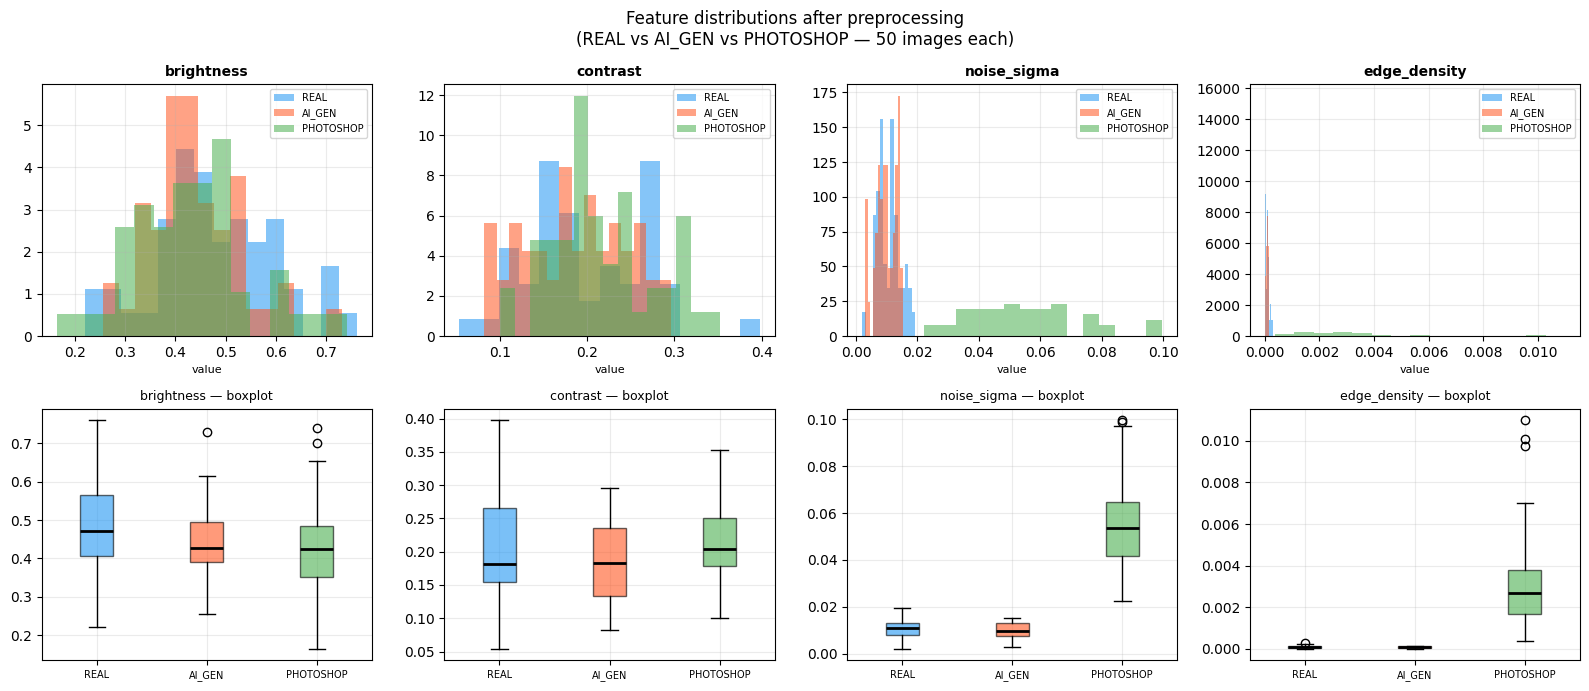

Feature          REAL mean±std             AI_GEN mean±std           PHOTOSHOP mean±std        Diff R↔PS
----------------------------------------------------------------------------------------------------
brightness       0.4819 ± 0.1209          0.4405 ± 0.0885          0.4279 ± 0.1158          AI:8.6%  PS:11.2%
contrast         0.1992 ± 0.0685          0.1867 ± 0.0595          0.2173 ± 0.0577          AI:6.2%  PS:9.1%
noise_sigma      0.0108 ± 0.0037          0.0098 ± 0.0034          0.0552 ± 0.0180          AI:9.1%  PS:412.4%
edge_density     0.0001 ± 0.0001          0.0001 ± 0.0000          0.0032 ± 0.0023          AI:19.9%  PS:3159.1%


In [80]:
import csv

# ── Load features CSV ─────────────────────────────────────────────────────
with open(PROCESSED / "features.csv") as f:
    reader = csv.DictReader(f)
    rows   = list(reader)

real_rows = [r for r in rows if r["label"] == "real"]
fake_rows = [r for r in rows if r["label"] == "ai_gen"]
ps_rows   = [r for r in rows if r["label"] == "photoshop"]

print(f"Loaded: {len(real_rows)} REAL, {len(fake_rows)} AI_GEN, {len(ps_rows)} PHOTOSHOP rows")

features = ["brightness", "contrast", "noise_sigma", "edge_density"]
colors   = {"real": "#2196F3", "ai_gen": "#FF5722", "photoshop": "#4CAF50"}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for fi, feat in enumerate(features):
    real_vals = [float(r[feat]) for r in real_rows]
    fake_vals = [float(r[feat]) for r in fake_rows]
    ps_vals   = [float(r[feat]) for r in ps_rows]

    # ── Row 1: histograms ─────────────────────────────────────────────────
    ax = axes[0][fi]
    ax.hist(real_vals, bins=15, color=colors["real"],      alpha=0.55, label="REAL",      density=True)
    ax.hist(fake_vals, bins=15, color=colors["ai_gen"],    alpha=0.55, label="AI_GEN",    density=True)
    ax.hist(ps_vals,   bins=15, color=colors["photoshop"], alpha=0.55, label="PHOTOSHOP", density=True)
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_xlabel("value", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)

    # ── Row 2: box plots ──────────────────────────────────────────────────
    ax2 = axes[1][fi]
    bp  = ax2.boxplot(
        [real_vals, fake_vals, ps_vals],
        labels=["REAL", "AI_GEN", "PHOTOSHOP"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2)
    )
    for patch, color in zip(bp["boxes"], [colors["real"], colors["ai_gen"], colors["photoshop"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax2.set_title(f"{feat} — boxplot", fontsize=9)
    ax2.tick_params(axis="x", labelsize=7)
    ax2.grid(alpha=0.25)

plt.suptitle("Feature distributions after preprocessing\n(REAL vs AI_GEN vs PHOTOSHOP — 50 images each)", fontsize=12)
plt.tight_layout(); plt.show()

# ── Print mean ± std ──────────────────────────────────────────────────────
print(f"{'Feature':<15}  {'REAL mean±std':<24}  {'AI_GEN mean±std':<24}  {'PHOTOSHOP mean±std':<24}  Diff R↔PS")
print("-" * 100)
for feat in features:
    rv = np.array([float(r[feat]) for r in real_rows])
    fv = np.array([float(r[feat]) for r in fake_rows])
    pv = np.array([float(r[feat]) for r in ps_rows])
    diff_ai = abs(rv.mean() - fv.mean()) / (rv.mean() + 1e-9) * 100
    diff_ps = abs(rv.mean() - pv.mean()) / (rv.mean() + 1e-9) * 100
    print(f"{feat:<15}  {rv.mean():.4f} ± {rv.std():.4f}          "
          f"{fv.mean():.4f} ± {fv.std():.4f}          "
          f"{pv.mean():.4f} ± {pv.std():.4f}          "
          f"AI:{diff_ai:.1f}%  PS:{diff_ps:.1f}%")

## Step 9 · Preview final processed images

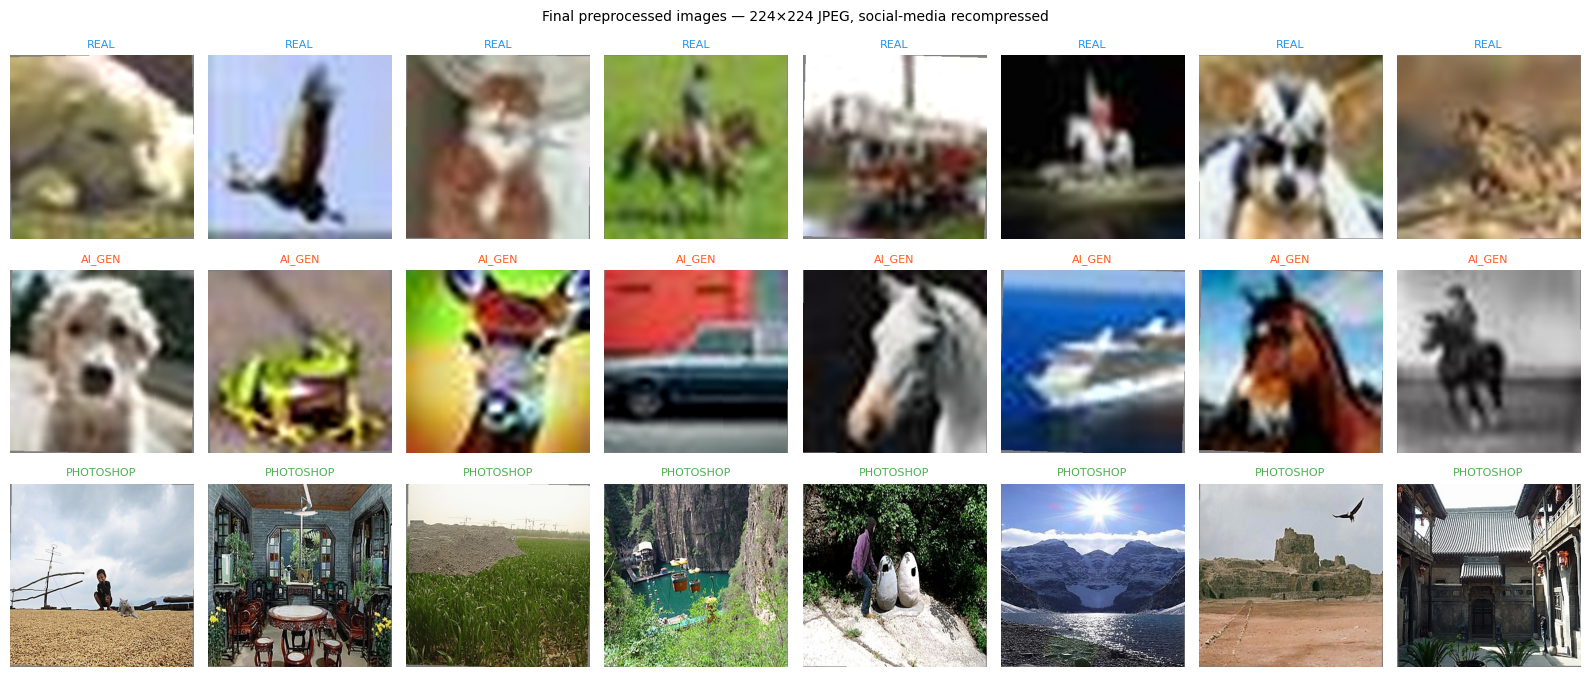

In [21]:
fig, axes = plt.subplots(3, 8, figsize=(16, 7))

real_files = sorted((PROCESSED/"real").glob("*.jpg"))[:8]
fake_files = sorted((PROCESSED/"ai_generated").glob("*.jpg"))[:8]
ps_files   = sorted((PROCESSED/"photoshop").glob("*.jpg"))[:8]

for ax, path in zip(axes[0], real_files):
    ax.imshow(Image.open(path)); ax.axis("off")
    ax.set_title("REAL", fontsize=8, color="#2196F3")

for ax, path in zip(axes[1], fake_files):
    ax.imshow(Image.open(path)); ax.axis("off")
    ax.set_title("AI_GEN", fontsize=8, color="#FF5722")

for ax, path in zip(axes[2], ps_files):
    ax.imshow(Image.open(path)); ax.axis("off")
    ax.set_title("PHOTOSHOP", fontsize=8, color="#4CAF50")

plt.suptitle("Final preprocessed images — 224×224 JPEG, social-media recompressed", fontsize=10)
plt.tight_layout(); plt.show()

## Step 10 · Final folder structure

In [22]:
print("Final dataset structure:")
print()
print("  data/processed/")
for cls_folder in sorted(PROCESSED.iterdir()):
    if not cls_folder.is_dir(): continue
    imgs  = list(cls_folder.glob("*.jpg"))
    total = len(imgs)
    target = 50
    bar = "█" * total + "░" * (target - min(total, target))
    status = "✓ ready" if total >= target else f"⚠ need {target - total} more"
    print(f"    {cls_folder.name}/ [{bar}] {total}/{target}  {status}")

Final dataset structure:

  data/processed/
    .ipynb_checkpoints/ [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0/50  ⚠ need 50 more
    ai_generated/ [██████████████████████████████████████████████████] 50/50  ✓ ready
    photoshop/ [████████████████████████████████████████████████████████████████████████████████████████████████████] 100/50  ✓ ready
    real/ [██████████████████████████████████████████████████] 50/50  ✓ ready


## Summary — what each preprocessing step does

```
Original CIFAKE image (32×32 px, from Kaggle)
        │
        ▼
[1] Resize → 224×224 px (LANCZOS)
        │   Needed: MobileNet-V3 requires exactly 224×224
        ▼
[2] Augment (train images only)
        │   Random flip + brightness ±15% + contrast ±15% + rotation ±8°
        │   Why: you only have 50 images — augmentation triples effective variety
        ▼
[3] JPEG recompression (quality 70–85, random)
        │   Why: Facebook, Twitter, LINE all recompress uploaded images
        │   Your model must detect fakes even after platform compression
        ▼
[4] Save as clean JPEG (quality 95)
        │   The compressed version is what gets saved and fed to the model
        ▼
[5] Extract features: brightness, contrast, noise_sigma, edge_density
        │   These go into the hand-crafted branch of the dual-branch model
        ▼
data/processed/real/real_001.jpg  …  real_050.jpg
data/processed/ai_generated/ai_gen_001.jpg  …  ai_gen_050.jpg
```

> **Note on CIFAKE image size:** CIFAKE images are 32×32 px — the resize to 224×224
> will look blurry/pixelated. This is expected and fine for training.
> When you use real social media images (Unsplash, Midjourney) they are much higher resolution
> and the preprocessing will produce sharper results.


## 3 · Feature engineering — brightness, contrast, noise, colour

In [26]:
# ── 11 Hand-crafted detection features ───────────────────────────────────

def extract_features(pil_img: Image.Image) -> np.ndarray:
    """
    Extract 11 statistical features from a PIL image.

    Features
    --------
    0  brightness_mean   — mean luminance (Y channel)
    1  brightness_std    — std of luminance (uniform AI images → low std)
    2  contrast_rms      — RMS contrast across the image
    3  noise_sigma       — estimated sensor noise (high-freq residual)
    4  edge_density      — Laplacian variance (sharpness indicator)
    5  r_mean            — mean of Red channel
    6  g_mean            — mean of Green channel
    7  b_mean            — mean of Blue channel
    8  colour_entropy    — Shannon entropy of quantised colour histogram
    9  local_var_cv      — coefficient of variation of 16x16 patch variances
                           (low = copy-paste regions from Photoshop)
    10 jpeg_block_score  — 8×8 DCT block artifact score
    """
    img_rgb  = np.array(pil_img.convert("RGB"), dtype=np.float32)
    img_gray = np.array(pil_img.convert("L"),   dtype=np.float32)
    h, w     = img_gray.shape

    # ── 0, 1: brightness ─────────────────────────────────────────────────
    brightness_mean = img_gray.mean() / 255.0
    brightness_std  = img_gray.std()  / 255.0

    # ── 2: RMS contrast ───────────────────────────────────────────────────
    contrast_rms = np.sqrt(np.mean((img_gray - img_gray.mean())**2)) / 255.0

    # ── 3: noise sigma (difference from Gaussian-blurred version) ─────────
    blurred     = cv2.GaussianBlur(img_gray, (5, 5), 0)
    residual    = img_gray - blurred
    noise_sigma = residual.std() / 255.0

    # ── 4: edge density via Laplacian variance ────────────────────────────
    lap          = cv2.Laplacian(img_gray.astype(np.uint8), cv2.CV_64F)
    edge_density = lap.var() / 1e6   # normalise

    # ── 5, 6, 7: per-channel means ────────────────────────────────────────
    r_mean = img_rgb[:, :, 0].mean() / 255.0
    g_mean = img_rgb[:, :, 1].mean() / 255.0
    b_mean = img_rgb[:, :, 2].mean() / 255.0

    # ── 8: colour histogram entropy ───────────────────────────────────────
    hist, _ = np.histogram(img_gray.flatten(), bins=32, range=(0, 256))
    hist    = hist / hist.sum() + 1e-9
    colour_entropy = -np.sum(hist * np.log2(hist)) / np.log2(32)  # normalise 0-1

    # ── 9: local variance coefficient of variation (copy-paste detector) ──
    patch = 16
    variances = []
    for y in range(0, h - patch + 1, patch):
        for x in range(0, w - patch + 1, patch):
            block = img_gray[y:y+patch, x:x+patch]
            variances.append(block.var())
    variances      = np.array(variances) + 1e-9
    local_var_cv   = variances.std() / variances.mean()  # low = suspicious

    # ── 10: JPEG 8×8 DCT block artifact score ─────────────────────────────
    block_scores = []
    for y in range(0, h - 8 + 1, 8):
        for x in range(0, w - 8 + 1, 8):
            block = img_gray[y:y+8, x:x+8]
            dct   = cv2.dct(block.astype(np.float32))
            block_scores.append(np.abs(dct[4:, 4:]).mean())  # high-freq energy
    jpeg_block_score = np.mean(block_scores) / 255.0

    return np.array([
        brightness_mean, brightness_std, contrast_rms,
        noise_sigma, edge_density,
        r_mean, g_mean, b_mean,
        colour_entropy, local_var_cv, jpeg_block_score
    ], dtype=np.float32)

FEATURE_NAMES = [
    "brightness_mean", "brightness_std", "contrast_rms",
    "noise_sigma", "edge_density",
    "r_mean", "g_mean", "b_mean",
    "colour_entropy", "local_var_cv", "jpeg_block_score"
]
NUM_FEATURES = len(FEATURE_NAMES)
print(f"Feature extractor ready — {NUM_FEATURES} features per image")
print("\nFeatures:")
for i, name in enumerate(FEATURE_NAMES):
    print(f"  [{i:02d}] {name}")


Feature extractor ready — 11 features per image

Features:
  [00] brightness_mean
  [01] brightness_std
  [02] contrast_rms
  [03] noise_sigma
  [04] edge_density
  [05] r_mean
  [06] g_mean
  [07] b_mean
  [08] colour_entropy
  [09] local_var_cv
  [10] jpeg_block_score


In [27]:
# ── Visualise features across classes ────────────────────────────────────
DATA_DIR = Path("data/processed")

folder_map = {
    0: DATA_DIR / "real",
    1: DATA_DIR / "ai_generated",
    2: DATA_DIR / "photoshop"
}

print("Extracting features from all images...")
all_feats, all_labels = [], []
for class_id, folder in folder_map.items():
    imgs = list(folder.glob("*.jpg")) + list(folder.glob("*.png"))
    for path in tqdm(imgs, desc=f"  {CLASS_NAMES[class_id]:<12}"):
        try:
            img   = Image.open(path).convert("RGB").resize((256, 256))
            feats = extract_features(img)
            all_feats.append(feats)
            all_labels.append(class_id)
        except Exception as e:
            print(f"  skip {path.name}: {e}")

X = np.array(all_feats)
y = np.array(all_labels)
print(f"\nTotal images : {len(X)}")
for cid in range(3):
    print(f"  {CLASS_NAMES[cid]:<12}: {(y==cid).sum()}")


Extracting features from all images...


  PHOTOSHOP   : 100%|████████████████████████████████████████████████████████████████| 100/100 [00:06<00:00, 16.27it/s]


Total images : 200
  REAL        : 50
  AI_GEN      : 50
  PHOTOSHOP   : 100


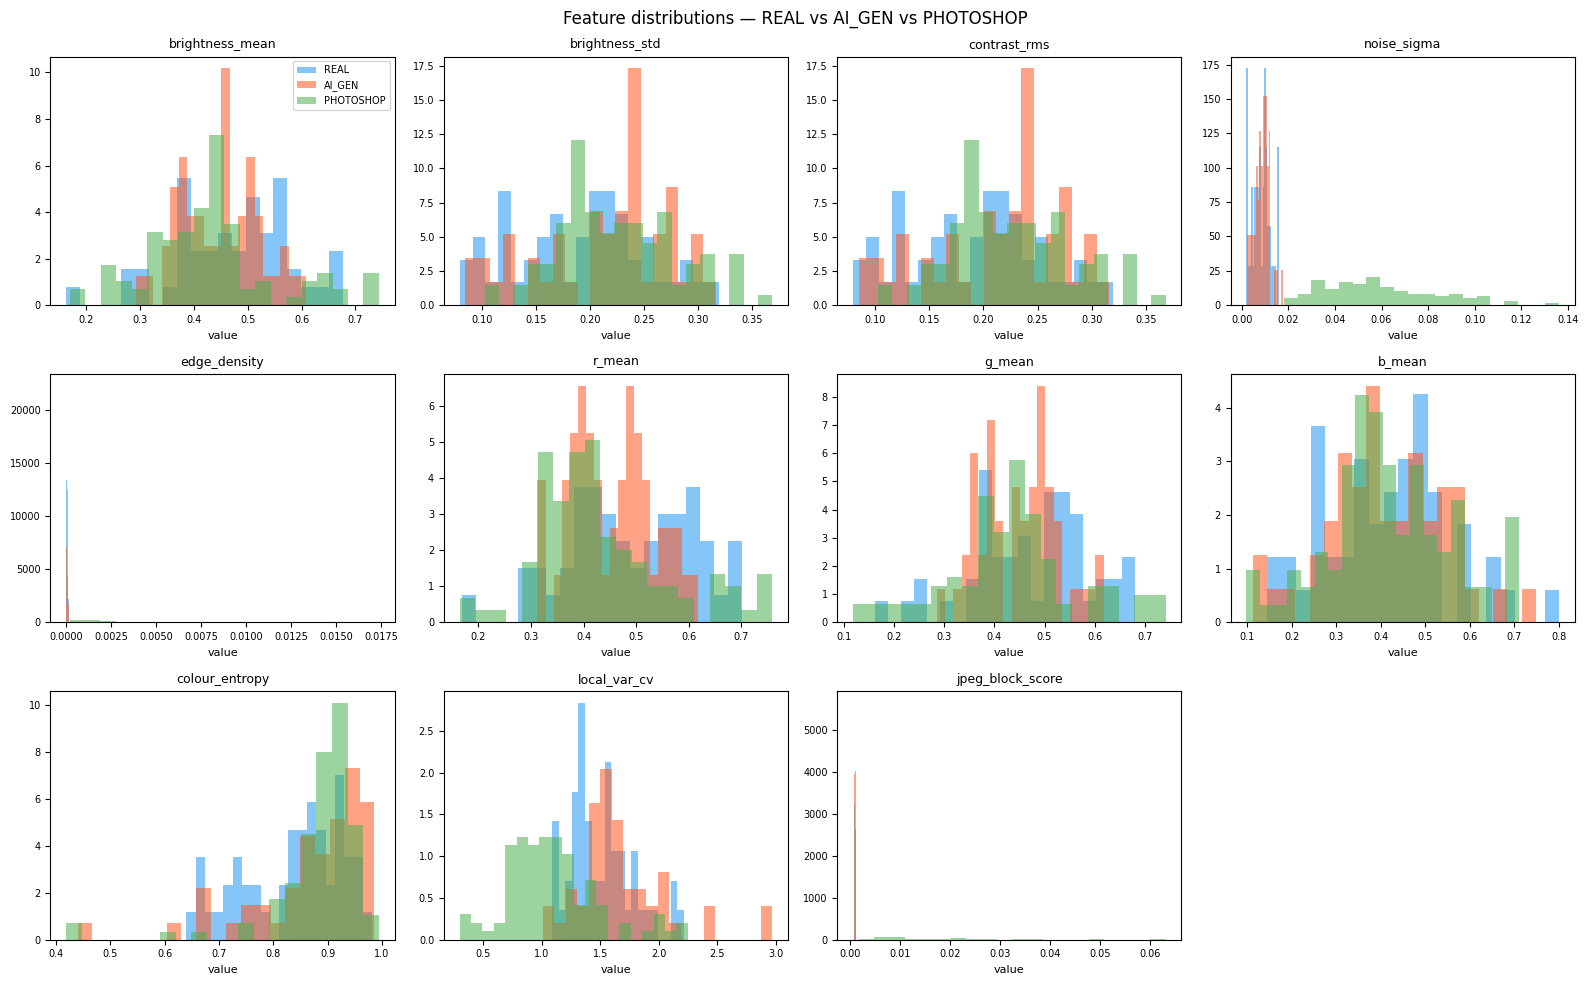


Mean feature values per class:
Feature               REAL          AI_GEN        PHOTOSHOP   
------------------------------------------------------------
brightness_mean             0.4729        0.4478        0.4310
brightness_std              0.1897        0.2151        0.2259
contrast_rms                0.1897        0.2151        0.2259
noise_sigma                 0.0083        0.0086        0.0598
edge_density                0.0001        0.0001        0.0036
r_mean                      0.4916        0.4553        0.4348
g_mean                      0.4751        0.4503        0.4319
b_mean                      0.4122        0.4142        0.4164
colour_entropy              0.8355        0.8703        0.8824
local_var_cv                1.5066        1.6798        1.0895
jpeg_block_score            0.0010        0.0010        0.0181


In [28]:
# ── Feature distribution plots ────────────────────────────────────────────
colors = ["#2196F3", "#FF5722", "#4CAF50"]
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for fi, fname in enumerate(FEATURE_NAMES):
    ax = axes[fi]
    for cid in range(3):
        vals = X[y == cid, fi]
        ax.hist(vals, bins=20, alpha=0.55, color=colors[cid],
                label=CLASS_NAMES[cid], density=True)
    ax.set_title(fname, fontsize=9)
    ax.set_xlabel("value", fontsize=8)
    ax.tick_params(labelsize=7)
    if fi == 0:
        ax.legend(fontsize=7)

# Hide empty subplot
axes[-1].set_visible(False)

plt.suptitle("Feature distributions — REAL vs AI_GEN vs PHOTOSHOP", fontsize=12)
plt.tight_layout()
plt.show()

print("\nMean feature values per class:")
print(f"{'Feature':<20}", end="")
for cid in range(3): print(f"  {CLASS_NAMES[cid]:<12}", end="")
print()
print("-" * 60)
for fi, fname in enumerate(FEATURE_NAMES):
    print(f"{fname:<20}", end="")
    for cid in range(3):
        print(f"  {X[y==cid, fi].mean():>12.4f}", end="")
    print()


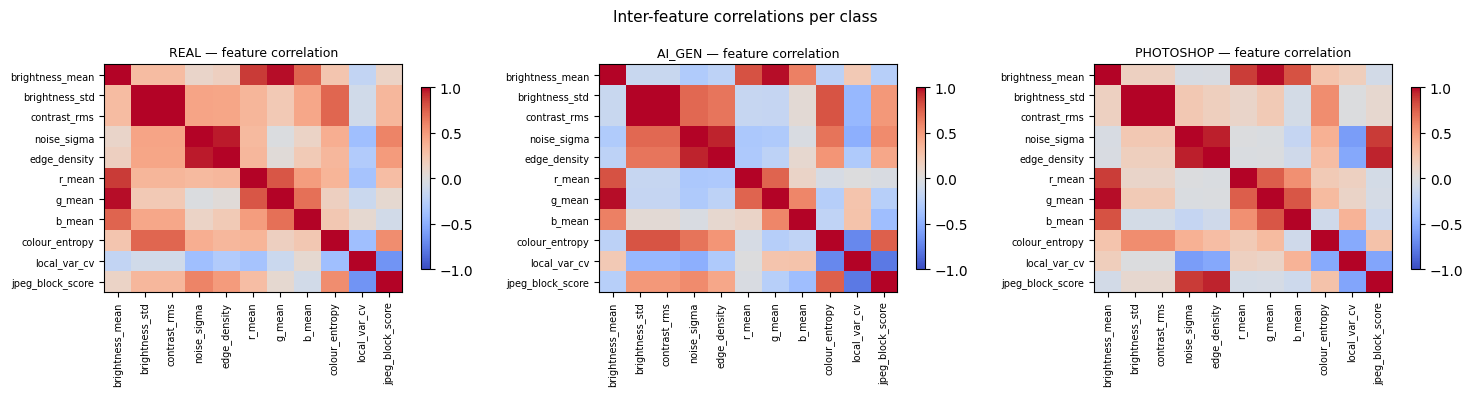

In [29]:
# ── Correlation heatmap ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for cid, ax in enumerate(axes):
    subset = X[y == cid]
    corr   = np.corrcoef(subset.T)
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
    ax.set_xticks(range(NUM_FEATURES)); ax.set_xticklabels(FEATURE_NAMES, rotation=90, fontsize=7)
    ax.set_yticks(range(NUM_FEATURES)); ax.set_yticklabels(FEATURE_NAMES, fontsize=7)
    ax.set_title(f"{CLASS_NAMES[cid]} — feature correlation", fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Inter-feature correlations per class", fontsize=11)
plt.tight_layout()
plt.show()


## 4 · Dataset class & data loaders

In [32]:
# ── Gather all image paths and labels ────────────────────────────────────
from sklearn.model_selection import train_test_split

SEED = 42

all_paths  = []
all_lbls   = []
for class_id, folder in folder_map.items():
    for p in sorted(folder.glob("*.jpg")) + sorted(list(folder.glob("*.png"))):
        all_paths.append(str(p))
        all_lbls.append(class_id)

all_paths = np.array(all_paths)
all_lbls  = np.array(all_lbls)

# ── Train / val / test split: 70 / 15 / 15 ───────────────────────────────
idx = np.arange(len(all_paths))
idx_tv, idx_test = train_test_split(idx, test_size=0.15, stratify=all_lbls, random_state=SEED)
idx_train, idx_val = train_test_split(idx_tv, test_size=0.176, stratify=all_lbls[idx_tv], random_state=SEED)

print(f"Train : {len(idx_train)} images")
print(f"Val   : {len(idx_val)}   images")
print(f"Test  : {len(idx_test)}  images")


Train : 140 images
Val   : 30   images
Test  : 30  images


In [35]:
# ── Imports ──────────────────────────────────────────────────────────────
import torch
import torchvision.transforms as T

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

# ── Constants ────────────────────────────────────────────────────────────
IMG_SIZE   = 224

BATCH_SIZE = 16

NUM_CLASSES = 3

# ── Image transforms ─────────────────────────────────────────────────────
train_transform = T.Compose([

    T.Resize((IMG_SIZE, IMG_SIZE)),

    T.RandomHorizontalFlip(),

    T.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),

    T.RandomRotation(8),

    T.ToTensor(),

    T.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])

val_transform = T.Compose([

    T.Resize((IMG_SIZE, IMG_SIZE)),

    T.ToTensor(),

    T.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])

# ── Dataset class ────────────────────────────────────────────────────────
class VeriTrustDataset(Dataset):
    """
    Returns:
        image_tensor,
        feature_vector,
        label
    """

    def __init__(
        self,
        paths,
        labels,
        transform
    ):

        self.paths = paths

        self.labels = labels

        self.transform = transform

    def __len__(self):

        return len(self.paths)

    def __getitem__(self, idx):

        # ── Load image ──────────────────────────────
        img = Image.open(
            self.paths[idx]
        ).convert("RGB")

        # ── Hand-crafted features ───────────────────
        feats = extract_features(

            img.resize((256, 256))

        )

        # convert → tensor
        feats = torch.tensor(
            feats,
            dtype=torch.float32
        )

        # ── CNN image transform ─────────────────────
        img_t = self.transform(img)

        label = int(
            self.labels[idx]
        )

        return img_t, feats, label

# ── Build datasets ───────────────────────────────────────────────────────
train_ds = VeriTrustDataset(
    all_paths[idx_train],
    all_lbls[idx_train],
    train_transform
)

val_ds = VeriTrustDataset(
    all_paths[idx_val],
    all_lbls[idx_val],
    val_transform
)

test_ds = VeriTrustDataset(
    all_paths[idx_test],
    all_lbls[idx_test],
    val_transform
)

# ── Weighted sampler (class balancing) ──────────────────────────────────
train_lbls = all_lbls[idx_train]

class_cnts = np.bincount(
    train_lbls,
    minlength=NUM_CLASSES
)

print("Class counts:")
print(class_cnts)

class_wts = 1.0 / class_cnts

sample_wts = class_wts[
    train_lbls
]

sampler = WeightedRandomSampler(
    sample_wts,
    len(sample_wts),
    replacement=True
)

# ── DataLoaders ──────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(
    f"\nLoaders ready — "
    f"{len(train_loader)} train batches, "
    f"{len(val_loader)} val batches, "
    f"{len(test_loader)} test batches"
)

Class counts:
[35 35 70]

Loaders ready — 9 train batches, 2 val batches, 2 test batches


## 5 · Dual-branch MobileNet-V3 model

The model has **two input branches**:

```
Image ──► MobileNet-V3 backbone ──► 960-d CNN features ──┐
                                                           ├──► Fusion MLP ──► 3-class output
Hand-crafted features (11-d) ──► Feature MLP (11→64) ────┘
```

This lets the model combine deep visual patterns (learned by CNN) with explicit
statistical signals (brightness, noise, contrast) that we know are discriminative.


In [ ]:
class VeriTrustDualBranch(nn.Module):
    """
    Dual-branch classifier:
      Branch A — MobileNet-V3-Large CNN (pretrained ImageNet)
      Branch B — small MLP for hand-crafted features (brightness, noise, etc.)
      Fusion   — concatenate both → 3-class softmax
    """
    def __init__(self, num_features: int = 11, num_classes: int = 3,
                 unfreeze_last: int = 3):
        super().__init__()

        # ── Branch A: MobileNet-V3 backbone ──────────────────────────────
        mob            = tv_models.mobilenet_v3_large(
            weights=tv_models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
        )
        self.cnn       = mob.features
        self.pool      = mob.avgpool         # → (B, 960, 1, 1)
        cnn_dim        = 960

        # Freeze all, unfreeze last N blocks
        for p in self.cnn.parameters():
            p.requires_grad = False
        for layer in list(self.cnn.children())[-unfreeze_last:]:
            for p in layer.parameters():
                p.requires_grad = True

        # ── Branch B: hand-crafted feature MLP ───────────────────────────
        feat_dim       = 64
        self.feat_mlp  = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.ReLU(),
            nn.Linear(32, feat_dim),
            nn.ReLU(),
        )

        # ── Fusion head ───────────────────────────────────────────────────
        fused_dim      = cnn_dim + feat_dim   # 960 + 64 = 1024
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(fused_dim, 256),
            nn.Hardswish(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),      # 3-class logits
        )

    def forward(self, img: torch.Tensor, feats: torch.Tensor) -> torch.Tensor:
        # Branch A
        x_cnn  = self.pool(self.cnn(img)).flatten(1)    # (B, 960)
        # Branch B
        x_feat = self.feat_mlp(feats)                   # (B, 64)
        # Fusion
        x_fuse = torch.cat([x_cnn, x_feat], dim=1)     # (B, 1024)
        return self.classifier(x_fuse)                  # (B, 3)


model = VeriTrustDualBranch(
    num_features=NUM_FEATURES,
    num_classes=NUM_CLASSES,
    unfreeze_last=3
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params : {trainable:,}")
print(f"Frozen params    : {total - trainable:,}")
print(f"Total params     : {total:,}")


## 6 · Training with MLflow

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────
LR           = 5e-4
WEIGHT_DECAY = 1e-2
EPOCHS       = 30
PATIENCE     = 7      # early stopping patience

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


In [ ]:
# ── Helper functions ──────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0
    for imgs, feats, labels in tqdm(loader, desc="  train", leave=False):
        imgs, feats, labels = imgs.to(DEVICE), feats.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs, feats)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, feats, labels in tqdm(loader, desc="  eval ", leave=False):
        imgs, feats, labels = imgs.to(DEVICE), feats.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs, feats)
        loss   = criterion(logits, labels)
        probs  = F.softmax(logits, dim=1)
        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    acc = correct / total
    f1  = f1_score(all_labels, all_preds, average="macro")
    return total_loss / total, acc, f1, np.array(all_preds), np.array(all_labels), np.array(all_probs)

print("Training helpers defined.")


In [ ]:
# ── MLflow training loop ──────────────────────────────────────────────────
history = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","val_f1"]}

mlflow.set_experiment("veritrust-3class")

with mlflow.start_run(run_name="mobilenetv3-dual-branch"):
    mlflow.log_params({
        "backbone"      : "mobilenet_v3_large",
        "branches"      : "CNN + hand-crafted features",
        "num_features"  : NUM_FEATURES,
        "num_classes"   : NUM_CLASSES,
        "lr"            : LR,
        "epochs"        : EPOCHS,
        "batch_size"    : BATCH_SIZE,
        "label_smoothing": 0.1,
        "unfreeze_last" : 3,
    })

    best_f1        = 0.0
    patience_cnt   = 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc           = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc, vl_f1, _, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        history["val_f1"].append(vl_f1)

        mlflow.log_metrics({"train_loss":tr_loss,"val_loss":vl_loss,
                            "train_acc":tr_acc,"val_acc":vl_acc,"val_f1":vl_f1}, step=epoch)

        improved = "✓" if vl_f1 > best_f1 else " "
        print(f"Epoch {epoch:02d}/{EPOCHS} {improved} | "
              f"loss {tr_loss:.4f}→{vl_loss:.4f} | "
              f"acc {tr_acc:.3f}→{vl_acc:.3f} | f1 {vl_f1:.3f}")

        if vl_f1 > best_f1:
            best_f1      = vl_f1
            patience_cnt = 0
            torch.save(model.state_dict(), "veritrust_3class_best.pt")
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch} (patience={PATIENCE})")
                break

    mlflow.log_artifact("veritrust_3class_best.pt")
    mlflow.pytorch.log_model(model, "veritrust_3class_model")
    print(f"\n✓ Best macro F1: {best_f1:.4f}")


In [ ]:
# ── Training curves ───────────────────────────────────────────────────────
ep = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(ep, history["train_loss"], label="train"); axes[0].plot(ep, history["val_loss"], label="val", linestyle="--")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history["train_acc"], label="train"); axes[1].plot(ep, history["val_acc"], label="val", linestyle="--")
axes[1].set_title("Accuracy"); axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history["val_f1"], color="green")
axes[2].set_title("Val macro F1"); axes[2].set_ylim(0, 1); axes[2].grid(alpha=0.3)

plt.suptitle("VeriTrust 3-class training curves", fontsize=12)
plt.tight_layout(); plt.show()


## 7 · Evaluation — confusion matrix, per-class metrics, feature importance

In [ ]:
# ── Load best model and evaluate on test set ──────────────────────────────
model.load_state_dict(torch.load("veritrust_3class_best.pt", map_location=DEVICE))
_, test_acc, test_f1, y_pred, y_true, y_probs = evaluate(model, test_loader, criterion)

print("=" * 55)
print("VeriTrust 3-class — test set results")
print("=" * 55)
print(f"  Accuracy   : {test_acc:.4f}")
print(f"  Macro F1   : {test_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


In [ ]:
# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title("Confusion matrix — counts")

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_title("Confusion matrix — % of true class")

plt.suptitle("VeriTrust test-set confusion matrices", fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
# ── Per-class confidence score distributions ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ["#2196F3", "#FF5722", "#4CAF50"]

for cid, ax in enumerate(axes):
    true_mask  = y_true == cid
    ax.hist(y_probs[true_mask, cid], bins=20, color=colors[cid], alpha=0.7, label="True class")
    ax.hist(y_probs[~true_mask, cid], bins=20, color="gray", alpha=0.4, label="Other classes")
    ax.set_title(f"{CLASS_NAMES[cid]} confidence"); ax.set_xlabel("Softmax score")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Per-class confidence score distribution", fontsize=11)
plt.tight_layout(); plt.show()

In [ ]:
# ── Feature importance (permutation importance on test set) ───────────────
# For each feature, shuffle it and measure drop in accuracy
@torch.no_grad()
def permutation_importance(model, loader, base_acc):
    model.eval()
    importances = []
    for fi in range(NUM_FEATURES):
        correct = total = 0
        for imgs, feats, labels in loader:
            imgs, feats, labels = imgs.to(DEVICE), feats.to(DEVICE), labels.to(DEVICE)
            perm_feats = feats.clone()
            idx_perm   = torch.randperm(perm_feats.size(0))
            perm_feats[:, fi] = perm_feats[idx_perm, fi]   # shuffle feature fi
            preds  = model(imgs, perm_feats).argmax(1)
            correct += (preds == labels).sum().item()
            total   += imgs.size(0)
        drop = base_acc - correct / total
        importances.append(drop)
    return importances

print("Computing permutation feature importance (takes ~30 s)...")
importances = permutation_importance(model, test_loader, test_acc)

# Plot
order = np.argsort(importances)[::-1]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(
    [FEATURE_NAMES[i] for i in order],
    [importances[i] for i in order],
    color=["#D32F2F" if importances[i] > 0 else "#90A4AE" for i in order]
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Accuracy drop when feature is shuffled")
ax.set_title("Permutation feature importance\n(higher = more important for classification)")
plt.tight_layout(); plt.show()

print("\nTop-5 most important features:")
for rank, fi in enumerate(order[:5], 1):
    print(f"  {rank}. {FEATURE_NAMES[fi]:<22} drop={importances[fi]:+.4f}")


## 8 · Live inference — predict any image

In [ ]:
# ── Single-image predict function ─────────────────────────────────────────
THRESHOLDS = {"confident": 0.65, "uncertain": 0.45}

def predict_image(image_path_or_pil, use_model=True):
    """
    Run full VeriTrust pipeline on one image.

    Returns a dict with:
        verdict      : REAL | AI_GEN | PHOTOSHOP | UNCERTAIN
        confidence   : float (max softmax score)
        scores       : {class: probability}
        features     : dict of 11 extracted feature values
        signals      : list of human-readable detection signals
    """
    if isinstance(image_path_or_pil, (str, Path)):
        img = Image.open(image_path_or_pil).convert("RGB")
    else:
        img = image_path_or_pil.convert("RGB")

    # ── Extract hand-crafted features ────────────────────────────────────
    feats   = extract_features(img.resize((256, 256)))
    feat_d  = dict(zip(FEATURE_NAMES, feats))

    # ── CNN inference ─────────────────────────────────────────────────────
    model.eval()
    img_t    = val_transform(img).unsqueeze(0).to(DEVICE)
    feat_t   = torch.tensor(feats).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(img_t, feat_t)
        probs  = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    pred_idx    = probs.argmax()
    confidence  = float(probs[pred_idx])
    verdict     = CLASS_NAMES[pred_idx] if confidence >= THRESHOLDS["uncertain"] else "UNCERTAIN"

    # ── Human-readable signal explanations ───────────────────────────────
    signals = []
    if feat_d["noise_sigma"] < 0.015:
        signals.append("⚠ Very low noise — typical of AI generation")
    if feat_d["brightness_std"] < 0.08:
        signals.append("⚠ Uniform brightness — AI images are too smooth")
    if feat_d["local_var_cv"] < 0.5:
        signals.append("⚠ Low local variance — possible copy-paste (Photoshop)")
    if feat_d["edge_density"] > 0.05:
        signals.append("⚠ High edge density — sharp artificial edges detected")
    if feat_d["colour_entropy"] < 0.65:
        signals.append("⚠ Low colour entropy — limited colour range (AI pattern)")
    if not signals:
        signals.append("✓ No strong manipulation signals detected")

    return {
        "verdict"    : verdict,
        "confidence" : confidence,
        "scores"     : dict(zip(CLASS_NAMES, probs.tolist())),
        "features"   : feat_d,
        "signals"    : signals,
    }

print("predict_image() ready.")


In [ ]:
# ── Run on test images and show results ───────────────────────────────────
n_show   = 8
sample_idx = random.sample(range(len(test_ds)), n_show)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
VERDICT_COLORS = {"REAL":"#2196F3","AI_GEN":"#FF5722","PHOTOSHOP":"#4CAF50","UNCERTAIN":"#9E9E9E"}

for ax, idx in zip(axes.flat, sample_idx):
    path, true_lbl = all_paths[idx_test[idx]], all_lbls[idx_test[idx]]
    result         = predict_image(path)
    img_disp       = Image.open(path).resize((224, 224))
    ax.imshow(img_disp)
    ax.axis("off")
    col = VERDICT_COLORS.get(result["verdict"], "gray")
    ax.set_title(
        f"Pred: {result['verdict']}  ({result['confidence']*100:.0f}%)\n"
        f"True: {CLASS_NAMES[true_lbl]}",
        fontsize=8, color=col, fontweight="bold"
    )

plt.suptitle("Live inference — 8 test samples", fontsize=11)
plt.tight_layout(); plt.show()


In [ ]:
# ── Detailed single-image breakdown ──────────────────────────────────────
# Change this path to any image you want to analyse
sample_path = all_paths[idx_test[0]]
result      = predict_image(sample_path)

print("=" * 55)
print(f"  File      : {Path(sample_path).name}")
print(f"  Verdict   : {result['verdict']}")
print(f"  Confidence: {result['confidence']*100:.1f}%")
print()
print("  Class probabilities:")
for cls, score in result["scores"].items():
    bar = "█" * int(score * 30) + "░" * (30 - int(score * 30))
    print(f"    {cls:<12} {bar}  {score*100:.1f}%")
print()
print("  Detection signals:")
for s in result["signals"]:
    print(f"    {s}")
print()
print("  Extracted features:")
for name, val in result["features"].items():
    print(f"    {name:<22}: {val:.5f}")


## 9 · Summary

| Component | Detail |
|-----------|--------|
| Model | MobileNet-V3-Large dual-branch (CNN + feature MLP) |
| Classes | REAL · AI_GEN · PHOTOSHOP |
| Dataset | 50 + 50 + 50 images (replace synthetics with real data) |
| Key features | brightness, contrast, noise σ, edge density, colour entropy, local variance, JPEG DCT |
| Training | AdamW + CosineAnnealingLR, label smoothing 0.1, early stopping |
| Tracking | MLflow experiment `veritrust-3class` |

### What to do next

1. **Replace synthetic data** — drop your 150 real images into `data/real/`, `data/ai_generated/`, `data/photoshop/` and re-run from Cell 4
2. **Scale up** — add more images per class (aim for 200+ per class) to improve generalisation
3. **Add DDCD / CIFAKE** — use code from previous notebook to merge larger datasets
4. **Wire to FastAPI** — export model, wrap `predict_image()` in a `/detect` endpoint
5. **Knowledge distillation** — use EfficientNet-B4 as teacher to recover accuracy on more nuanced cases
